# 🤖 Step 3: Model Training & Evaluation

This notebook trains and evaluates **5 different regression models** plus a **Stacking Ensemble**:

| # | Model | Type |
|---|-------|------|
| 1 | XGBoost | Gradient Boosting |
| 2 | Random Forest | Bagging Ensemble |
| 3 | LightGBM | Gradient Boosting |
| 4 | Ridge | Linear (L2 Regularization) |
| 5 | Lasso | Linear (L1 Regularization) |
| 6 | Stacking Ensemble | Meta-model (XGB + RF + Lasso → Ridge) |

Each model includes:
- GridSearchCV hyperparameter tuning
- 5-Fold Stratified Cross-Validation
- SHAP explainability analysis
- Per-player prediction export (Excel)

**Input:** `df_filtred3` from Step 2  
**Output:** Metrics, SHAP plots, Feature Importance plots, Excel predictions

## 3.0 Load Data (if not already in memory)

In [2]:
import pandas as pd
import numpy as np
import unicodedata
import warnings

warnings.filterwarnings('ignore')

# Reload and rebuild df_filtred3 if not in memory
try:
    df_filtred3.shape
    df_inner.shape
    print(f"df_filtred3 already in memory: {df_filtred3.shape}")
except NameError:
    df_stats = pd.read_csv("../data/nba_stats_2025_26.csv")
    df_salaries = pd.read_csv("../data/nba_salaries_2026_27.csv")
    
    def clean_name_simple(name):
        if pd.isna(name): return name
        name = unicodedata.normalize('NFKD', name).encode('ASCII', 'ignore').decode('utf-8')
        name = name.replace('.', '')
        return name.upper().strip()
    
    df_salaries["PLAYER_NAME"] = df_salaries["PLAYER_NAME"].apply(clean_name_simple)
    df_stats["PLAYER_NAME"] = df_stats["PLAYER_NAME"].apply(clean_name_simple)
    df_inner = pd.merge(df_stats, df_salaries, on="PLAYER_NAME", how="inner")
    
    rank_columns = [col for col in df_inner.columns if 'RANK' in col.upper()]
    df_norank = df_inner.drop(columns=rank_columns, errors='ignore')
    extras_to_drop = ['PLAYER_ID', 'PLAYER_NAME', 'TEAM_ABBREVIATION', 'NBA_FANTASY_PTS', 'WNBA_FANTASY_PTS', 'FP_HIGH_SCORE']
    df_filtred1 = df_norank.drop(columns=extras_to_drop, errors='ignore')
    manual_drop_list = ['FGM', 'FGA', 'FTM', 'FTA', 'FG3A', 'FG3M', 'DREB']
    df_filtred2 = df_filtred1.drop(columns=manual_drop_list, errors='ignore')
    vif_features_to_drop = ['W', 'L']
    df_filtred3 = df_filtred2.drop(columns=vif_features_to_drop, errors='ignore')
    
    print(f"df_filtred3 rebuilt from CSVs: {df_filtred3.shape}")

df_filtred3 already in memory: (379, 22)


## 3.1 Prepare Features and Target

In [3]:
import pandas as pd
import numpy as np
import warnings

# We turn off unnecessary warnings
warnings.filterwarnings('ignore')

# 1. TARGET VARIABLE (Y)
y = df_filtred3['SALARY']

# ==============================================================================
# 2. PREPARING THE DATASET (X)
# ==============================================================================
# We only use the features in the df_filtred3 dataframe. 
# We drop the salary target from X and fill empty values with 0.
X_final = df_filtred3.drop(columns=['SALARY'], errors='ignore').fillna(0)

# ==============================================================================
# 3. CREATING THE LOOP DICTIONARY
# ==============================================================================
# This is the single, cleanest package that the model will take in and test.
variations = {
    "Cleaned Final Data (df_filtred3)": X_final
}

print("\u2705 Clean data to be used for the model (X_final) successfully created and ready!")
print(f"A total of {X_final.shape[1]} features (columns) will be learned by the model.")

✅ Clean data to be used for the model (X_final) successfully created and ready!
A total of 21 features (columns) will be learned by the model.


---
## 3.2 XGBoost


🤖 MODEL: XGBOOST (FINE-TUNING, SHAP VE EXPORT RAPORLARI)

➤ Cleaned Final Data (df_filtred3) (Dosyalar 'XGBoost_Variation_1' adıyla kaydedilecek)
   🌟 En İyi Parametreler: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_child_weight': 7, 'model__n_estimators': 100}
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_child_weight': 7, 'model__n_estimators': 100}
1. K-Fold Train (Mean) -> R2:  0.9041 | RMSE: $ 4,525,789 | MAE: $ 3,320,532
2. K-Fold Val (Mean)   -> R2:  0.7110 | RMSE: $ 7,803,306 | MAE: $ 5,457,350
3. Full Data Overfit   -> R2:  0.8953 | RMSE: $ 4,734,294 | MAE: $ 3,488,599
4. 100% OOF PREDICTION -> R2:  0.7103 | RMSE: $ 7,873,739 | MAE: $ 5,457,536


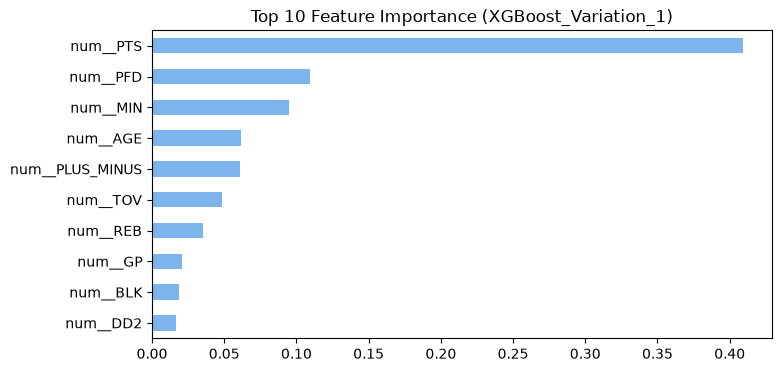

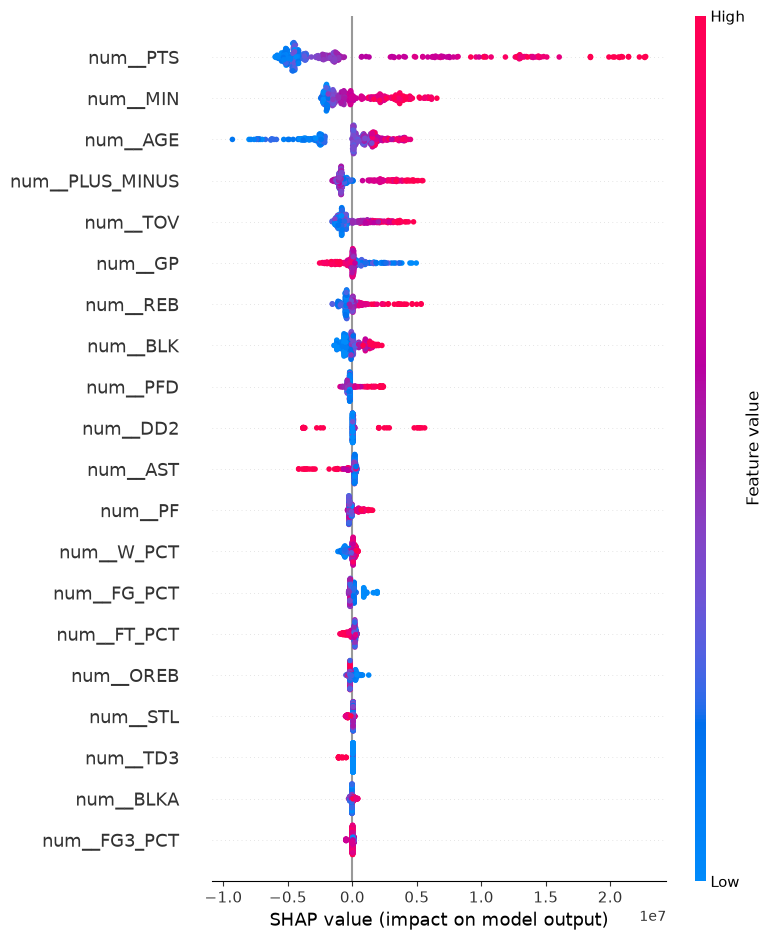

   🚨 EN UÇUK MAAŞ (Overpaid): 
     PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY  DIFFERENCE
  PAOLO BANCHERO       41500000       $11,580,065 $29,919,935
    JORDAN POOLE       34044642       $12,718,937 $21,325,705
JAREN JACKSON JR       49000000       $28,827,274 $20,172,726
   💎 EN HAKSIZ MAAŞ (Underpaid):
    PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY   DIFFERENCE
   LEBRON JAMES        3876529       $35,749,700 $-31,873,171
  DEMAR DEROZAN        2449421       $32,592,660 $-30,143,239
KEVIN PORTER JR        5390700       $34,376,444 $-28,985,744
----------------------------------------------------------------------------------------------------


In [4]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np

print("\n" + "="*100)
print("\U0001f916 MODEL: XGBOOST (FINE-TUNING, SHAP VE EXPORT RAPORLARI)")
print("="*100)

gelir_gruplari_tum = pd.qcut(y, q=5, labels=False, duplicates='drop')

for idx, (var_name, X) in enumerate(variations.items(), start=1):
    
    file_prefix = f"XGBoost_Variation_{idx}"
    print(f"\n\u27a4 {var_name} (Dosyalar '{file_prefix}' ad\u0131yla kaydedilecek)")
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_splits = list(skf.split(X, gelir_gruplari_tum))
    
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols) 
    ])
    
    pipe = Pipeline([('preprocessor', preprocessor), ('model', XGBRegressor(random_state=42))])
    param_grid = {
        'model__n_estimators': [100, 200], 
        'model__max_depth': [1, 2, 3, 5], 
        'model__learning_rate': [0.05, 0.1, 0.2, 0.3], 
        'model__min_child_weight': [1, 3, 5, 7]
    }
    
    grid = GridSearchCV(pipe, param_grid, cv=cv_splits, scoring='r2', n_jobs=-1)
    grid.fit(X, y)
    best_pipe = grid.best_estimator_
    
    cv_res = cross_validate(best_pipe, X, y, cv=cv_splits, scoring=('r2', 'neg_mean_absolute_error', 'neg_mean_squared_error'), return_train_score=True, n_jobs=-1)
    y_pred_full = best_pipe.predict(X)
    y_pred_oof = cross_val_predict(best_pipe, X, y, cv=cv_splits, n_jobs=-1)
    
    report_text = f"--- {file_prefix} METRICS ---\n"
    report_text += f"Best Parameters: {grid.best_params_}\n"
    report_text += f"1. K-Fold Train (Mean) -> R2: {cv_res['train_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['train_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['train_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"2. K-Fold Val (Mean)   -> R2: {cv_res['test_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['test_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['test_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"3. Full Data Overfit   -> R2: {r2_score(y, y_pred_full):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_full)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_full):10,.0f}\n"
    report_text += f"4. 100% OOF PREDICTION -> R2: {r2_score(y, y_pred_oof):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_oof)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_oof):10,.0f}\n"
    
    print(f"   \U0001f31f En \u0130yi Parametreler: {grid.best_params_}")
    print(report_text.split("---")[2].strip())
    
    with open(f"../outputs/metrics/{file_prefix}_Metrics_and_Params.txt", "w", encoding="utf-8") as f:
        f.write(report_text)
    
    feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
    plt.figure(figsize=(8, 4))
    importances = pd.Series(best_pipe.named_steps['model'].feature_importances_, index=feature_names)
    importances.nlargest(10).sort_values().plot(kind='barh', color='#7cb5ec')
    plt.title(f'Top 10 Feature Importance ({file_prefix})')
    plt.savefig(f"../outputs/plots/{file_prefix}_Feature_Importance.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    X_shap_df = pd.DataFrame(best_pipe.named_steps['preprocessor'].transform(X), columns=feature_names)
    explainer = shap.TreeExplainer(best_pipe.named_steps['model'])
    shap.summary_plot(explainer.shap_values(X_shap_df), X_shap_df, plot_type="dot", show=False)
    plt.savefig(f"../outputs/plots/{file_prefix}_SHAP.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    desired_cols = ['PLAYER_NAME', 'PLAYER_ID', 'TEAM_ABBREVIATION', 'TEAM', 'AGE', 'GP', 'W_PCT', 'MIN', 
                    'FGA', 'FG_PCT', 'FG3A', 'FG3_PCT', 'PTS', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 
                    'PLUS_MINUS', 'DD2', 'TD3', 'SALARY']
    
    exist_cols = [c for c in desired_cols if c in df_inner.columns]
    df_export = df_inner[exist_cols].copy()
    
    if 'SALARY' in df_export.columns:
        df_export.rename(columns={'SALARY': 'ACTUAL_SALARY'}, inplace=True)
    
    df_export['PREDICTED_SALARY'] = y_pred_oof
    df_export['DIFFERENCE'] = df_export['ACTUAL_SALARY'] - df_export['PREDICTED_SALARY']
    df_export['ABS_ERROR'] = df_export['DIFFERENCE'].abs()
    
    df_error_sorted = df_export.sort_values(by='ABS_ERROR', ascending=False).copy()
    df_salary_sorted = df_export.sort_values(by='ACTUAL_SALARY', ascending=False).copy()
    
    def save_fancy_excel(df_to_save, file_name):
        writer = pd.ExcelWriter(file_name, engine='xlsxwriter')
        df_to_save.to_excel(writer, index=False, sheet_name='Predictions')
        workbook = writer.book
        worksheet = writer.sheets['Predictions']
        header_format = workbook.add_format({'bold': True, 'text_wrap': True, 'valign': 'top', 'align': 'center', 'fg_color': '#1f497d', 'font_color': 'white', 'border': 1})
        money_format = workbook.add_format({'num_format': '$#,##0', 'align': 'right'})
        number_format = workbook.add_format({'align': 'center'})
        for col_num, col_name in enumerate(df_to_save.columns):
            worksheet.write(0, col_num, col_name, header_format)
            max_len = max(df_to_save[col_name].astype(str).map(len).max(), len(col_name)) + 2
            if col_name in ['ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE', 'ABS_ERROR']:
                worksheet.set_column(col_num, col_num, max(max_len, 15), money_format)
            elif col_name == 'PLAYER_NAME':
                worksheet.set_column(col_num, col_num, max(max_len, 20))
            else:
                worksheet.set_column(col_num, col_num, max(max_len, 10), number_format)
            if col_name == 'DIFFERENCE':
                worksheet.conditional_format(1, col_num, len(df_to_save), col_num, {'type': '3_color_scale', 'min_color': '#63BE7B', 'mid_color': '#FFFFFF', 'max_color': '#F8696B'})
        writer.close()
    
    save_fancy_excel(df_error_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Error.xlsx")
    save_fancy_excel(df_salary_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Salary.xlsx")
    
    print(f"   \U0001f6a8 EN U\u00c7UK MAA\u015e (Overpaid): \n{df_export.sort_values('DIFFERENCE', ascending=False).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}")
    print(f"   \U0001f48e EN HAKSIZ MAA\u015e (Underpaid):\n{df_export.sort_values('DIFFERENCE', ascending=True).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}\n" + "-"*100)

---
## 3.3 Random Forest


🤖 MODEL: RANDOM FOREST (FINE-TUNING, SHAP VE EXPORT RAPORLARI)

➤ Cleaned Final Data (df_filtred3) (Dosyalar 'RandomForest_Variation_1' adıyla kaydedilecek)
   🌟 En İyi Parametreler: {'model__max_depth': 5, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best Parameters: {'model__max_depth': 5, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}
1. K-Fold Train (Mean) -> R2:  0.8764 | RMSE: $ 5,138,868 | MAE: $ 3,822,044
2. K-Fold Val (Mean)   -> R2:  0.6885 | RMSE: $ 8,100,375 | MAE: $ 5,770,504
3. Full Data Overfit   -> R2:  0.8659 | RMSE: $ 5,355,910 | MAE: $ 4,018,663
4. 100% OOF PREDICTION -> R2:  0.6918 | RMSE: $ 8,120,876 | MAE: $ 5,767,278


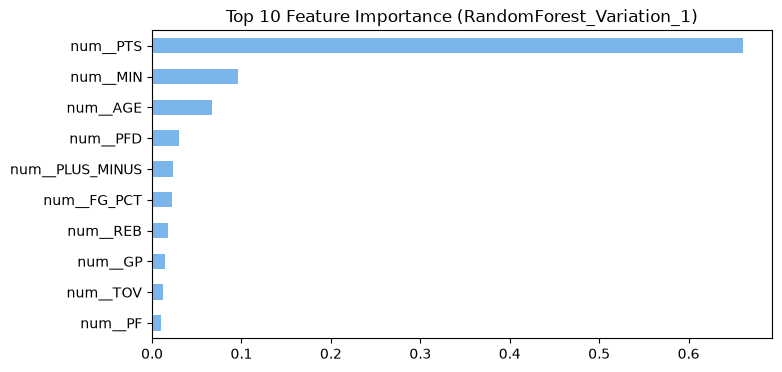

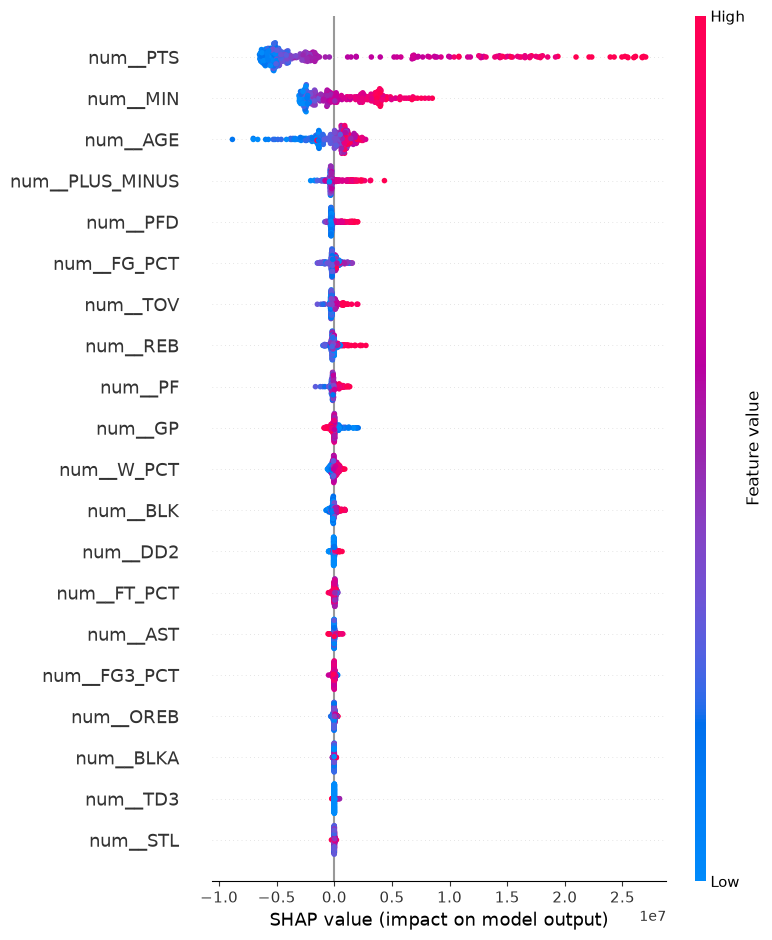

   🚨 EN UÇUK MAAŞ (Overpaid): 
     PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY  DIFFERENCE
DOMANTAS SABONIS       45472000       $20,314,603 $25,157,397
     ZACH LAVINE       48967380       $25,319,290 $23,648,090
    JAYSON TATUM       58456566       $35,584,216 $22,872,350
   💎 EN HAKSIZ MAAŞ (Underpaid):
  PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY   DIFFERENCE
 LEBRON JAMES        3876529       $40,223,210 $-36,346,681
DEMAR DEROZAN        2449421       $31,066,860 $-28,617,439
  DENI AVDIJA       13125000       $41,618,572 $-28,493,572
----------------------------------------------------------------------------------------------------


In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np

print("\n" + "="*100)
print("\U0001f916 MODEL: RANDOM FOREST (FINE-TUNING, SHAP VE EXPORT RAPORLARI)")
print("="*100)

gelir_gruplari_tum = pd.qcut(y, q=5, labels=False, duplicates='drop')

for idx, (var_name, X) in enumerate(variations.items(), start=1):
    
    file_prefix = f"RandomForest_Variation_{idx}"
    print(f"\n\u27a4 {var_name} (Dosyalar '{file_prefix}' ad\u0131yla kaydedilecek)")
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_splits = list(skf.split(X, gelir_gruplari_tum))
    
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols) 
    ])
    
    pipe = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
    
    param_grid = {
        'model__n_estimators': [100, 200], 
        'model__max_depth': [5, 10, 20, None],
        'model__min_samples_leaf': [1, 3, 5], 
        'model__min_samples_split': [2, 5, 10],
        'model__max_features': ['sqrt', 'log2', 1.0]
    }
    
    grid = GridSearchCV(pipe, param_grid, cv=cv_splits, scoring='r2', n_jobs=-1)
    grid.fit(X, y)
    best_pipe = grid.best_estimator_
    
    cv_res = cross_validate(best_pipe, X, y, cv=cv_splits, scoring=('r2', 'neg_mean_absolute_error', 'neg_mean_squared_error'), return_train_score=True, n_jobs=-1)
    y_pred_full = best_pipe.predict(X)
    y_pred_oof = cross_val_predict(best_pipe, X, y, cv=cv_splits, n_jobs=-1)
    
    report_text = f"--- {file_prefix} METRICS ---\n"
    report_text += f"Best Parameters: {grid.best_params_}\n"
    report_text += f"1. K-Fold Train (Mean) -> R2: {cv_res['train_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['train_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['train_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"2. K-Fold Val (Mean)   -> R2: {cv_res['test_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['test_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['test_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"3. Full Data Overfit   -> R2: {r2_score(y, y_pred_full):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_full)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_full):10,.0f}\n"
    report_text += f"4. 100% OOF PREDICTION -> R2: {r2_score(y, y_pred_oof):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_oof)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_oof):10,.0f}\n"
    
    print(f"   \U0001f31f En \u0130yi Parametreler: {grid.best_params_}")
    print(report_text.split("---")[2].strip())
    
    with open(f"../outputs/metrics/{file_prefix}_Metrics_and_Params.txt", "w", encoding="utf-8") as f:
        f.write(report_text)
    
    feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
    plt.figure(figsize=(8, 4))
    importances = pd.Series(best_pipe.named_steps['model'].feature_importances_, index=feature_names)
    importances.nlargest(10).sort_values().plot(kind='barh', color='#7cb5ec')
    plt.title(f'Top 10 Feature Importance ({file_prefix})')
    plt.savefig(f"../outputs/plots/{file_prefix}_Feature_Importance.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    X_shap_df = pd.DataFrame(best_pipe.named_steps['preprocessor'].transform(X), columns=feature_names)
    explainer = shap.TreeExplainer(best_pipe.named_steps['model'])
    shap.summary_plot(explainer.shap_values(X_shap_df), X_shap_df, plot_type="dot", show=False)
    plt.savefig(f"../outputs/plots/{file_prefix}_SHAP.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    desired_cols = ['PLAYER_NAME', 'PLAYER_ID', 'TEAM_ABBREVIATION', 'TEAM', 'AGE', 'GP', 'W_PCT', 'MIN', 
                    'FGA', 'FG_PCT', 'FG3A', 'FG3_PCT', 'PTS', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 
                    'PLUS_MINUS', 'DD2', 'TD3', 'SALARY']
    exist_cols = [c for c in desired_cols if c in df_inner.columns]
    df_export = df_inner[exist_cols].copy()
    if 'SALARY' in df_export.columns:
        df_export.rename(columns={'SALARY': 'ACTUAL_SALARY'}, inplace=True)
    df_export['PREDICTED_SALARY'] = y_pred_oof
    df_export['DIFFERENCE'] = df_export['ACTUAL_SALARY'] - df_export['PREDICTED_SALARY']
    df_export['ABS_ERROR'] = df_export['DIFFERENCE'].abs()
    df_error_sorted = df_export.sort_values(by='ABS_ERROR', ascending=False).copy()
    df_salary_sorted = df_export.sort_values(by='ACTUAL_SALARY', ascending=False).copy()
    
    def save_fancy_excel(df_to_save, file_name):
        writer = pd.ExcelWriter(file_name, engine='xlsxwriter')
        df_to_save.to_excel(writer, index=False, sheet_name='Predictions')
        workbook = writer.book
        worksheet = writer.sheets['Predictions']
        header_format = workbook.add_format({'bold': True, 'text_wrap': True, 'valign': 'top', 'align': 'center', 'fg_color': '#1f497d', 'font_color': 'white', 'border': 1})
        money_format = workbook.add_format({'num_format': '$#,##0', 'align': 'right'})
        number_format = workbook.add_format({'align': 'center'})
        for col_num, col_name in enumerate(df_to_save.columns):
            worksheet.write(0, col_num, col_name, header_format)
            max_len = max(df_to_save[col_name].astype(str).map(len).max(), len(col_name)) + 2
            if col_name in ['ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE', 'ABS_ERROR']:
                worksheet.set_column(col_num, col_num, max(max_len, 15), money_format)
            elif col_name == 'PLAYER_NAME':
                worksheet.set_column(col_num, col_num, max(max_len, 20))
            else:
                worksheet.set_column(col_num, col_num, max(max_len, 10), number_format)
            if col_name == 'DIFFERENCE':
                worksheet.conditional_format(1, col_num, len(df_to_save), col_num, {'type': '3_color_scale', 'min_color': '#63BE7B', 'mid_color': '#FFFFFF', 'max_color': '#F8696B'})
        writer.close()
    
    save_fancy_excel(df_error_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Error.xlsx")
    save_fancy_excel(df_salary_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Salary.xlsx")
    
    print(f"   \U0001f6a8 EN U\u00c7UK MAA\u015e (Overpaid): \n{df_export.sort_values('DIFFERENCE', ascending=False).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}")
    print(f"   \U0001f48e EN HAKSIZ MAA\u015e (Underpaid):\n{df_export.sort_values('DIFFERENCE', ascending=True).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}\n" + "-"*100)

---
## 3.4 LightGBM


🤖 MODEL: LIGHTGBM (FINE-TUNING, SHAP VE EXPORT RAPORLARI)

➤ Cleaned Final Data (df_filtred3) (Dosyalar 'LightGBM_Variation_1' adıyla kaydedilecek)
   🌟 En İyi Parametreler: {'model__learning_rate': 0.05, 'model__n_estimators': 100, 'model__num_leaves': 50}
Best Parameters: {'model__learning_rate': 0.05, 'model__n_estimators': 100, 'model__num_leaves': 50}
1. K-Fold Train (Mean) -> R2:  0.9120 | RMSE: $ 4,330,126 | MAE: $ 2,849,038
2. K-Fold Val (Mean)   -> R2:  0.6696 | RMSE: $ 8,312,895 | MAE: $ 5,679,299
3. Full Data Overfit   -> R2:  0.9182 | RMSE: $ 4,184,366 | MAE: $ 2,706,311
4. 100% OOF PREDICTION -> R2:  0.6745 | RMSE: $ 8,345,928 | MAE: $ 5,684,153


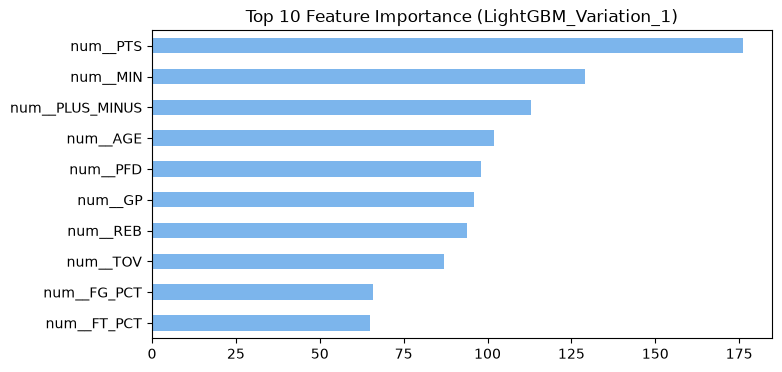

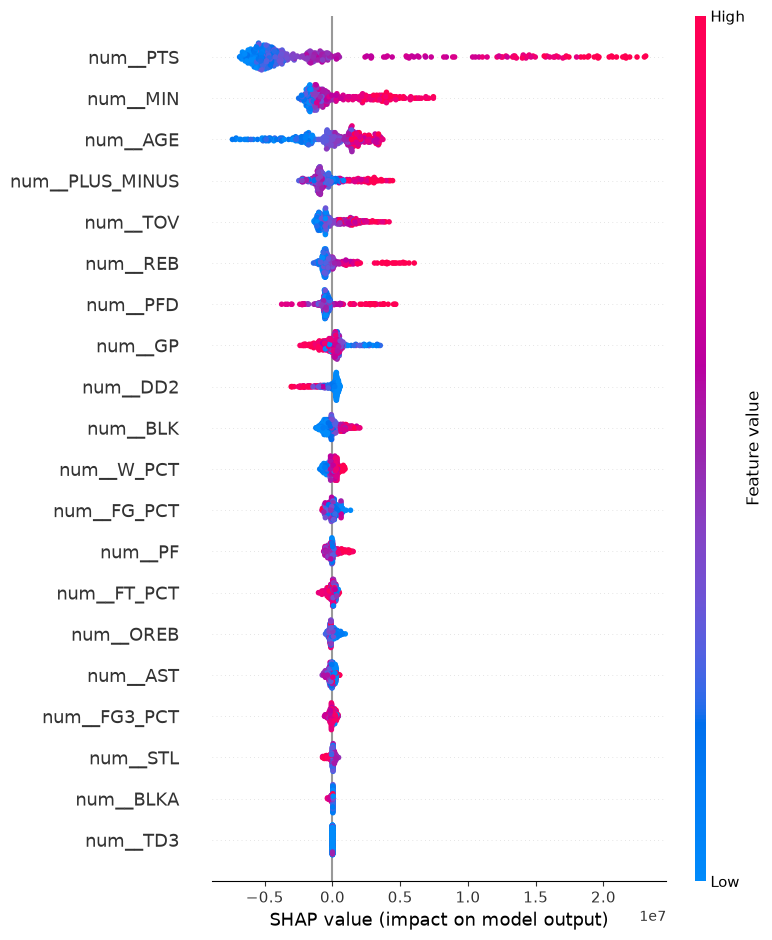

   🚨 EN UÇUK MAAŞ (Overpaid): 
     PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY  DIFFERENCE
     PAUL GEORGE       54126380       $29,164,943 $24,961,437
   STEPHEN CURRY       62587158       $39,244,638 $23,342,520
DOMANTAS SABONIS       45472000       $22,542,030 $22,929,970
   💎 EN HAKSIZ MAAŞ (Underpaid):
      PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY   DIFFERENCE
     LEBRON JAMES        3876529       $50,241,933 $-46,365,404
VICTOR WEMBANYAMA       16868246       $49,666,949 $-32,798,703
    DEMAR DEROZAN        2449421       $31,526,007 $-29,076,586
----------------------------------------------------------------------------------------------------


In [6]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np

print("\n" + "="*100)
print("\U0001f916 MODEL: LIGHTGBM (FINE-TUNING, SHAP VE EXPORT RAPORLARI)")
print("="*100)

gelir_gruplari_tum = pd.qcut(y, q=5, labels=False, duplicates='drop')

for idx, (var_name, X) in enumerate(variations.items(), start=1):
    
    file_prefix = f"LightGBM_Variation_{idx}"
    print(f"\n\u27a4 {var_name} (Dosyalar '{file_prefix}' ad\u0131yla kaydedilecek)")
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_splits = list(skf.split(X, gelir_gruplari_tum))
    
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols), 
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
    
    pipe = Pipeline([('preprocessor', preprocessor), ('model', LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1))])
    param_grid = {
        'model__n_estimators': [100, 200], 
        'model__num_leaves': [31, 50], 
        'model__learning_rate': [0.05, 0.1]
    }
    
    grid = GridSearchCV(pipe, param_grid, cv=cv_splits, scoring='r2', n_jobs=-1)
    grid.fit(X, y)
    best_pipe = grid.best_estimator_
    
    cv_res = cross_validate(best_pipe, X, y, cv=cv_splits, scoring=('r2', 'neg_mean_absolute_error', 'neg_mean_squared_error'), return_train_score=True, n_jobs=-1)
    y_pred_full = best_pipe.predict(X)
    y_pred_oof = cross_val_predict(best_pipe, X, y, cv=cv_splits, n_jobs=-1)
    
    report_text = f"--- {file_prefix} METRICS ---\n"
    report_text += f"Best Parameters: {grid.best_params_}\n"
    report_text += f"1. K-Fold Train (Mean) -> R2: {cv_res['train_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['train_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['train_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"2. K-Fold Val (Mean)   -> R2: {cv_res['test_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['test_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['test_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"3. Full Data Overfit   -> R2: {r2_score(y, y_pred_full):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_full)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_full):10,.0f}\n"
    report_text += f"4. 100% OOF PREDICTION -> R2: {r2_score(y, y_pred_oof):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_oof)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_oof):10,.0f}\n"
    
    print(f"   \U0001f31f En \u0130yi Parametreler: {grid.best_params_}")
    print(report_text.split("---")[2].strip())
    
    with open(f"../outputs/metrics/{file_prefix}_Metrics_and_Params.txt", "w", encoding="utf-8") as f:
        f.write(report_text)
    
    feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
    plt.figure(figsize=(8, 4))
    importances = pd.Series(best_pipe.named_steps['model'].feature_importances_, index=feature_names)
    importances.nlargest(10).sort_values().plot(kind='barh', color='#7cb5ec')
    plt.title(f'Top 10 Feature Importance ({file_prefix})')
    plt.savefig(f"../outputs/plots/{file_prefix}_Feature_Importance.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    X_shap_df = pd.DataFrame(best_pipe.named_steps['preprocessor'].transform(X), columns=feature_names)
    explainer = shap.TreeExplainer(best_pipe.named_steps['model'])
    shap.summary_plot(explainer.shap_values(X_shap_df), X_shap_df, plot_type="dot", show=False)
    plt.savefig(f"../outputs/plots/{file_prefix}_SHAP.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    desired_cols = ['PLAYER_NAME', 'PLAYER_ID', 'TEAM_ABBREVIATION', 'TEAM', 'AGE', 'GP', 'W_PCT', 'MIN', 
                    'FGA', 'FG_PCT', 'FG3A', 'FG3_PCT', 'PTS', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 
                    'PLUS_MINUS', 'DD2', 'TD3', 'SALARY']
    exist_cols = [c for c in desired_cols if c in df_inner.columns]
    df_export = df_inner[exist_cols].copy()
    if 'SALARY' in df_export.columns:
        df_export.rename(columns={'SALARY': 'ACTUAL_SALARY'}, inplace=True)
    df_export['PREDICTED_SALARY'] = y_pred_oof
    df_export['DIFFERENCE'] = df_export['ACTUAL_SALARY'] - df_export['PREDICTED_SALARY']
    df_export['ABS_ERROR'] = df_export['DIFFERENCE'].abs()
    df_error_sorted = df_export.sort_values(by='ABS_ERROR', ascending=False).copy()
    df_salary_sorted = df_export.sort_values(by='ACTUAL_SALARY', ascending=False).copy()
    
    def save_fancy_excel(df_to_save, file_name):
        writer = pd.ExcelWriter(file_name, engine='xlsxwriter')
        df_to_save.to_excel(writer, index=False, sheet_name='Predictions')
        workbook = writer.book
        worksheet = writer.sheets['Predictions']
        header_format = workbook.add_format({'bold': True, 'text_wrap': True, 'valign': 'top', 'align': 'center', 'fg_color': '#1f497d', 'font_color': 'white', 'border': 1})
        money_format = workbook.add_format({'num_format': '$#,##0', 'align': 'right'})
        number_format = workbook.add_format({'align': 'center'})
        for col_num, col_name in enumerate(df_to_save.columns):
            worksheet.write(0, col_num, col_name, header_format)
            max_len = max(df_to_save[col_name].astype(str).map(len).max(), len(col_name)) + 2
            if col_name in ['ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE', 'ABS_ERROR']:
                worksheet.set_column(col_num, col_num, max(max_len, 15), money_format)
            elif col_name == 'PLAYER_NAME':
                worksheet.set_column(col_num, col_num, max(max_len, 20))
            else:
                worksheet.set_column(col_num, col_num, max(max_len, 10), number_format)
            if col_name == 'DIFFERENCE':
                worksheet.conditional_format(1, col_num, len(df_to_save), col_num, {'type': '3_color_scale', 'min_color': '#63BE7B', 'mid_color': '#FFFFFF', 'max_color': '#F8696B'})
        writer.close()
    
    save_fancy_excel(df_error_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Error.xlsx")
    save_fancy_excel(df_salary_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Salary.xlsx")
    
    print(f"   \U0001f6a8 EN U\u00c7UK MAA\u015e (Overpaid): \n{df_export.sort_values('DIFFERENCE', ascending=False).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}")
    print(f"   \U0001f48e EN HAKSIZ MAA\u015e (Underpaid):\n{df_export.sort_values('DIFFERENCE', ascending=True).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}\n" + "-"*100)

---
## 3.5 Ridge Regression


🤖 MODEL: RIDGE (FINE-TUNING, SHAP VE EXPORT RAPORLARI)

➤ Cleaned Final Data (df_filtred3) (Dosyalar 'Ridge_Variation_1' adıyla kaydedilecek)
   🌟 En İyi Parametreler: {'model__alpha': 10.0}
Best Parameters: {'model__alpha': 10.0}
1. K-Fold Train (Mean) -> R2:  0.7056 | RMSE: $ 7,932,403 | MAE: $ 5,846,245
2. K-Fold Val (Mean)   -> R2:  0.6473 | RMSE: $ 8,585,892 | MAE: $ 6,270,042
3. Full Data Overfit   -> R2:  0.7012 | RMSE: $ 7,995,410 | MAE: $ 5,875,690
4. 100% OOF PREDICTION -> R2:  0.6528 | RMSE: $ 8,619,598 | MAE: $ 6,268,284


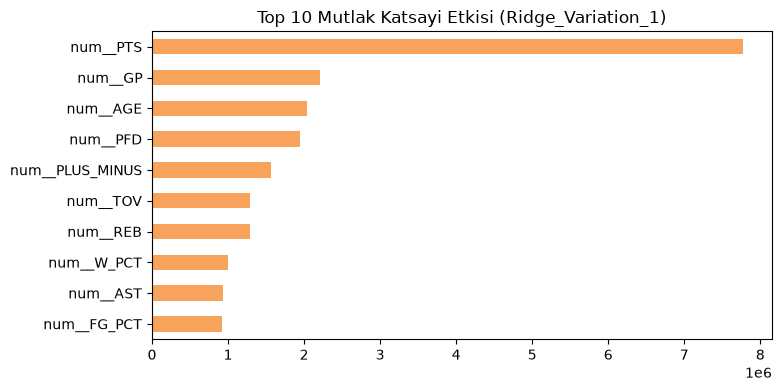

Background dataset has 379 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=379 when initializing the masker.


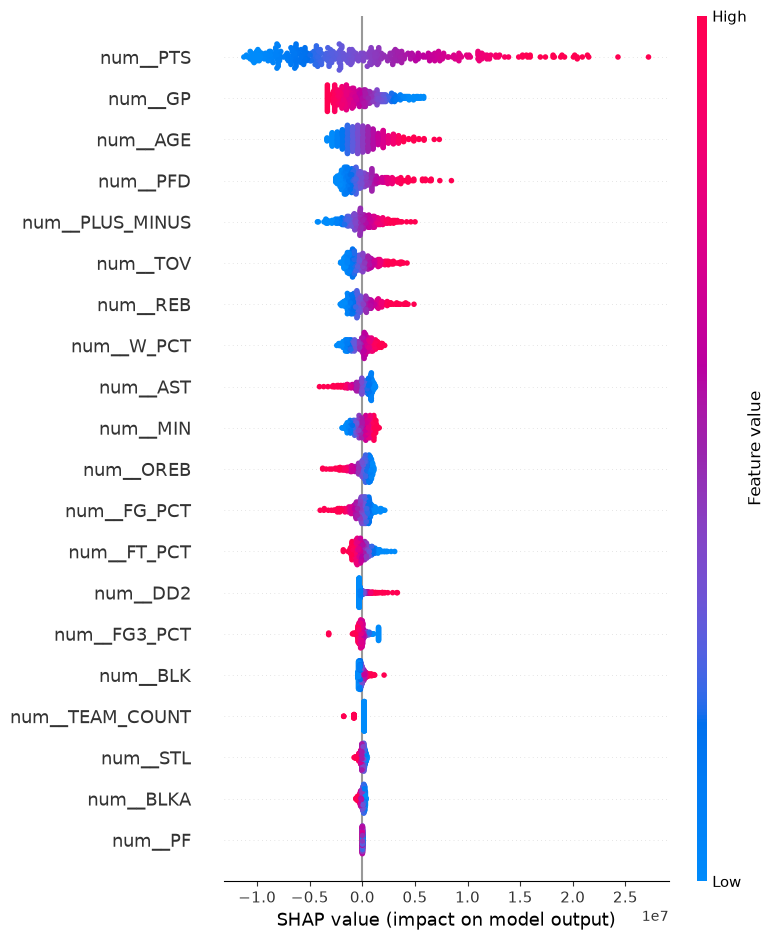

   🚨 EN UÇUK MAAŞ (Overpaid): 
       PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY  DIFFERENCE
      NIKOLA JOKIC       59033114       $32,441,238 $26,591,876
       ZACH LAVINE       48967380       $22,459,017 $26,508,363
KARL-ANTHONY TOWNS       57078728       $32,854,695 $24,224,033
   💎 EN HAKSIZ MAAŞ (Underpaid):
      PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY   DIFFERENCE
VICTOR WEMBANYAMA       16868246       $57,739,075 $-40,870,829
     LEBRON JAMES        3876529       $42,289,072 $-38,412,543
      DENI AVDIJA       13125000       $40,509,005 $-27,384,005
----------------------------------------------------------------------------------------------------


In [7]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np

print("\n" + "="*100)
print("\U0001f916 MODEL: RIDGE (FINE-TUNING, SHAP VE EXPORT RAPORLARI)")
print("="*100)

gelir_gruplari_tum = pd.qcut(y, q=5, labels=False, duplicates='drop')

for idx, (var_name, X) in enumerate(variations.items(), start=1):
    
    file_prefix = f"Ridge_Variation_{idx}"
    print(f"\n\u27a4 {var_name} (Dosyalar '{file_prefix}' ad\u0131yla kaydedilecek)")
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_splits = list(skf.split(X, gelir_gruplari_tum))
    
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols), 
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
    
    pipe = Pipeline([('preprocessor', preprocessor), ('model', Ridge(random_state=42))])
    param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
    
    grid = GridSearchCV(pipe, param_grid, cv=cv_splits, scoring='r2', n_jobs=-1)
    grid.fit(X, y)
    best_pipe = grid.best_estimator_
    
    cv_res = cross_validate(best_pipe, X, y, cv=cv_splits, scoring=('r2', 'neg_mean_absolute_error', 'neg_mean_squared_error'), return_train_score=True, n_jobs=-1)
    y_pred_full = best_pipe.predict(X)
    y_pred_oof = cross_val_predict(best_pipe, X, y, cv=cv_splits, n_jobs=-1)
    
    report_text = f"--- {file_prefix} METRICS ---\n"
    report_text += f"Best Parameters: {grid.best_params_}\n"
    report_text += f"1. K-Fold Train (Mean) -> R2: {cv_res['train_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['train_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['train_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"2. K-Fold Val (Mean)   -> R2: {cv_res['test_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['test_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['test_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"3. Full Data Overfit   -> R2: {r2_score(y, y_pred_full):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_full)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_full):10,.0f}\n"
    report_text += f"4. 100% OOF PREDICTION -> R2: {r2_score(y, y_pred_oof):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_oof)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_oof):10,.0f}\n"
    
    print(f"   \U0001f31f En \u0130yi Parametreler: {grid.best_params_}")
    print(report_text.split("---")[2].strip())
    
    with open(f"../outputs/metrics/{file_prefix}_Metrics_and_Params.txt", "w", encoding="utf-8") as f:
        f.write(report_text)
    
    feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
    plt.figure(figsize=(8, 4))
    importances = pd.Series(np.abs(best_pipe.named_steps['model'].coef_), index=feature_names)
    importances.nlargest(10).sort_values().plot(kind='barh', color='#f7a35c')
    plt.title(f'Top 10 Mutlak Katsayi Etkisi ({file_prefix})')
    plt.savefig(f"../outputs/plots/{file_prefix}_Katsayi_Etkisi.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    X_shap_df = pd.DataFrame(best_pipe.named_steps['preprocessor'].transform(X), columns=feature_names)
    explainer = shap.LinearExplainer(best_pipe.named_steps['model'], X_shap_df)
    shap.summary_plot(explainer.shap_values(X_shap_df), X_shap_df, plot_type="dot", show=False)
    plt.savefig(f"../outputs/plots/{file_prefix}_SHAP.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    desired_cols = ['PLAYER_NAME', 'PLAYER_ID', 'TEAM_ABBREVIATION', 'TEAM', 'AGE', 'GP', 'W_PCT', 'MIN', 
                    'FGA', 'FG_PCT', 'FG3A', 'FG3_PCT', 'PTS', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 
                    'PLUS_MINUS', 'DD2', 'TD3', 'SALARY']
    exist_cols = [c for c in desired_cols if c in df_inner.columns]
    df_export = df_inner[exist_cols].copy()
    if 'SALARY' in df_export.columns:
        df_export.rename(columns={'SALARY': 'ACTUAL_SALARY'}, inplace=True)
    df_export['PREDICTED_SALARY'] = y_pred_oof
    df_export['DIFFERENCE'] = df_export['ACTUAL_SALARY'] - df_export['PREDICTED_SALARY']
    df_export['ABS_ERROR'] = df_export['DIFFERENCE'].abs()
    df_error_sorted = df_export.sort_values(by='ABS_ERROR', ascending=False).copy()
    df_salary_sorted = df_export.sort_values(by='ACTUAL_SALARY', ascending=False).copy()
    
    def save_fancy_excel(df_to_save, file_name):
        writer = pd.ExcelWriter(file_name, engine='xlsxwriter')
        df_to_save.to_excel(writer, index=False, sheet_name='Predictions')
        workbook = writer.book
        worksheet = writer.sheets['Predictions']
        header_format = workbook.add_format({'bold': True, 'text_wrap': True, 'valign': 'top', 'align': 'center', 'fg_color': '#1f497d', 'font_color': 'white', 'border': 1})
        money_format = workbook.add_format({'num_format': '$#,##0', 'align': 'right'})
        number_format = workbook.add_format({'align': 'center'})
        for col_num, col_name in enumerate(df_to_save.columns):
            worksheet.write(0, col_num, col_name, header_format)
            max_len = max(df_to_save[col_name].astype(str).map(len).max(), len(col_name)) + 2
            if col_name in ['ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE', 'ABS_ERROR']:
                worksheet.set_column(col_num, col_num, max(max_len, 15), money_format)
            elif col_name == 'PLAYER_NAME':
                worksheet.set_column(col_num, col_num, max(max_len, 20))
            else:
                worksheet.set_column(col_num, col_num, max(max_len, 10), number_format)
            if col_name == 'DIFFERENCE':
                worksheet.conditional_format(1, col_num, len(df_to_save), col_num, {'type': '3_color_scale', 'min_color': '#63BE7B', 'mid_color': '#FFFFFF', 'max_color': '#F8696B'})
        writer.close()
    
    save_fancy_excel(df_error_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Error.xlsx")
    save_fancy_excel(df_salary_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Salary.xlsx")
    
    print(f"   \U0001f6a8 EN U\u00c7UK MAA\u015e (Overpaid): \n{df_export.sort_values('DIFFERENCE', ascending=False).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}")
    print(f"   \U0001f48e EN HAKSIZ MAA\u015e (Underpaid):\n{df_export.sort_values('DIFFERENCE', ascending=True).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}\n" + "-"*100)

---
## 3.6 Lasso Regression


🤖 MODEL: LASSO (FINE-TUNING, SHAP VE EXPORT RAPORLARI)

➤ Cleaned Final Data (df_filtred3) (Dosyalar 'Lasso_Variation_1' adıyla kaydedilecek)
   🌟 En İyi Parametreler: {'model__alpha': 100.0}
Best Parameters: {'model__alpha': 100.0}
1. K-Fold Train (Mean) -> R2:  0.7085 | RMSE: $ 7,892,536 | MAE: $ 5,850,231
2. K-Fold Val (Mean)   -> R2:  0.6404 | RMSE: $ 8,659,539 | MAE: $ 6,340,323
3. Full Data Overfit   -> R2:  0.7033 | RMSE: $ 7,967,930 | MAE: $ 5,892,259
4. 100% OOF PREDICTION -> R2:  0.6464 | RMSE: $ 8,698,836 | MAE: $ 6,338,584


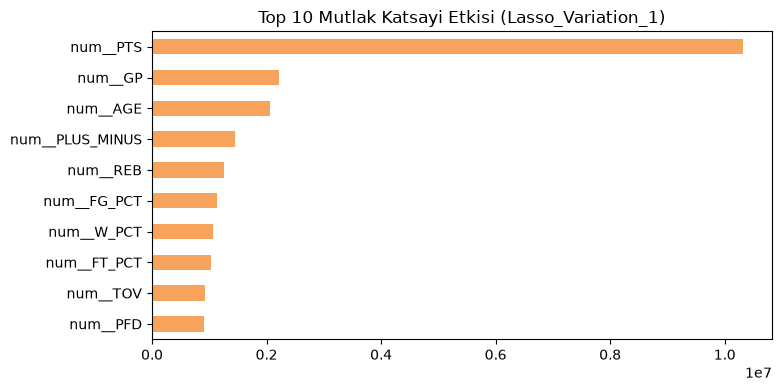

Background dataset has 379 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=379 when initializing the masker.


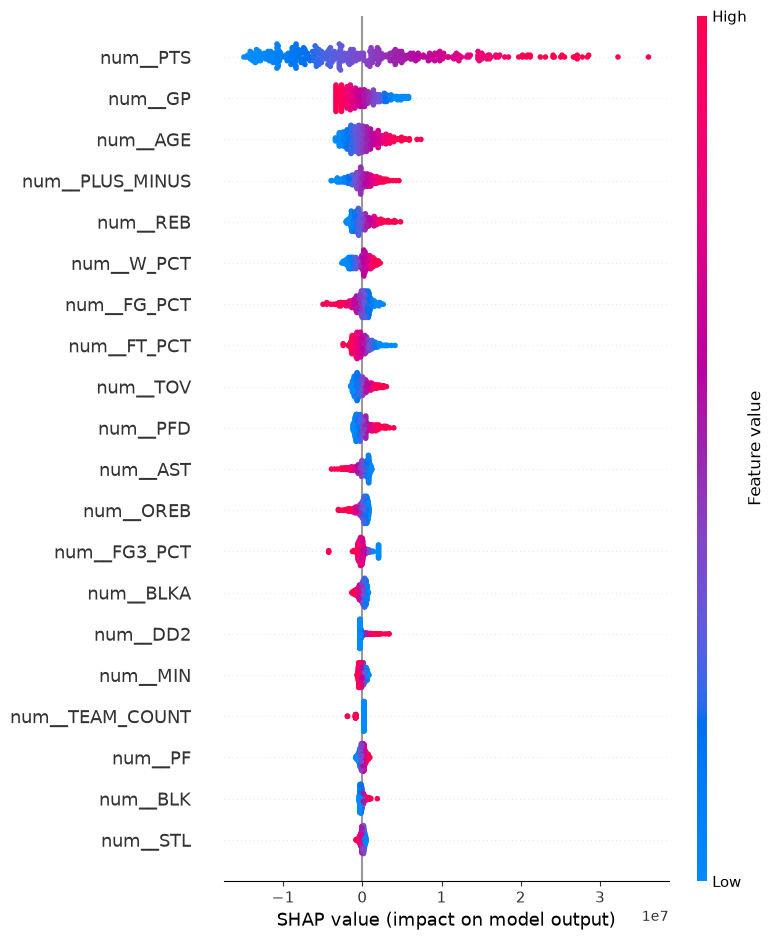

   🚨 EN UÇUK MAAŞ (Overpaid): 
       PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY  DIFFERENCE
      NIKOLA JOKIC       59033114       $30,669,692 $28,363,422
       ZACH LAVINE       48967380       $23,504,547 $25,462,833
KARL-ANTHONY TOWNS       57078728       $32,017,585 $25,061,143
   💎 EN HAKSIZ MAAŞ (Underpaid):
      PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY   DIFFERENCE
VICTOR WEMBANYAMA       16868246       $59,860,170 $-42,991,924
     LEBRON JAMES        3876529       $42,588,461 $-38,711,932
      DENI AVDIJA       13125000       $39,327,550 $-26,202,550
----------------------------------------------------------------------------------------------------


In [8]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np

print("\n" + "="*100)
print("\U0001f916 MODEL: LASSO (FINE-TUNING, SHAP VE EXPORT RAPORLARI)")
print("="*100)

gelir_gruplari_tum = pd.qcut(y, q=5, labels=False, duplicates='drop')

for idx, (var_name, X) in enumerate(variations.items(), start=1):
    
    file_prefix = f"Lasso_Variation_{idx}"
    print(f"\n\u27a4 {var_name} (Dosyalar '{file_prefix}' ad\u0131yla kaydedilecek)")
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_splits = list(skf.split(X, gelir_gruplari_tum))
    
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols), 
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
    
    pipe = Pipeline([('preprocessor', preprocessor), ('model', Lasso(random_state=42, max_iter=10000))])
    param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
    
    grid = GridSearchCV(pipe, param_grid, cv=cv_splits, scoring='r2', n_jobs=-1)
    grid.fit(X, y)
    best_pipe = grid.best_estimator_
    
    cv_res = cross_validate(best_pipe, X, y, cv=cv_splits, scoring=('r2', 'neg_mean_absolute_error', 'neg_mean_squared_error'), return_train_score=True, n_jobs=-1)
    y_pred_full = best_pipe.predict(X)
    y_pred_oof = cross_val_predict(best_pipe, X, y, cv=cv_splits, n_jobs=-1)
    
    report_text = f"--- {file_prefix} METRICS ---\n"
    report_text += f"Best Parameters: {grid.best_params_}\n"
    report_text += f"1. K-Fold Train (Mean) -> R2: {cv_res['train_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['train_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['train_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"2. K-Fold Val (Mean)   -> R2: {cv_res['test_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['test_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['test_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"3. Full Data Overfit   -> R2: {r2_score(y, y_pred_full):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_full)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_full):10,.0f}\n"
    report_text += f"4. 100% OOF PREDICTION -> R2: {r2_score(y, y_pred_oof):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_oof)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_oof):10,.0f}\n"
    
    print(f"   \U0001f31f En \u0130yi Parametreler: {grid.best_params_}")
    print(report_text.split("---")[2].strip())
    
    with open(f"../outputs/metrics/{file_prefix}_Metrics_and_Params.txt", "w", encoding="utf-8") as f:
        f.write(report_text)
    
    feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
    plt.figure(figsize=(8, 4))
    importances = pd.Series(np.abs(best_pipe.named_steps['model'].coef_), index=feature_names)
    importances.nlargest(10).sort_values().plot(kind='barh', color='#f7a35c')
    plt.title(f'Top 10 Mutlak Katsayi Etkisi ({file_prefix})')
    plt.savefig(f"../outputs/plots/{file_prefix}_Katsayi_Etkisi.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    X_shap_df = pd.DataFrame(best_pipe.named_steps['preprocessor'].transform(X), columns=feature_names)
    explainer = shap.LinearExplainer(best_pipe.named_steps['model'], X_shap_df)
    shap.summary_plot(explainer.shap_values(X_shap_df), X_shap_df, plot_type="dot", show=False)
    plt.savefig(f"../outputs/plots/{file_prefix}_SHAP.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    desired_cols = ['PLAYER_NAME', 'PLAYER_ID', 'TEAM_ABBREVIATION', 'TEAM', 'AGE', 'GP', 'W_PCT', 'MIN', 
                    'FGA', 'FG_PCT', 'FG3A', 'FG3_PCT', 'PTS', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 
                    'PLUS_MINUS', 'DD2', 'TD3', 'SALARY']
    exist_cols = [c for c in desired_cols if c in df_inner.columns]
    df_export = df_inner[exist_cols].copy()
    if 'SALARY' in df_export.columns:
        df_export.rename(columns={'SALARY': 'ACTUAL_SALARY'}, inplace=True)
    df_export['PREDICTED_SALARY'] = y_pred_oof
    df_export['DIFFERENCE'] = df_export['ACTUAL_SALARY'] - df_export['PREDICTED_SALARY']
    df_export['ABS_ERROR'] = df_export['DIFFERENCE'].abs()
    df_error_sorted = df_export.sort_values(by='ABS_ERROR', ascending=False).copy()
    df_salary_sorted = df_export.sort_values(by='ACTUAL_SALARY', ascending=False).copy()
    
    def save_fancy_excel(df_to_save, file_name):
        writer = pd.ExcelWriter(file_name, engine='xlsxwriter')
        df_to_save.to_excel(writer, index=False, sheet_name='Predictions')
        workbook = writer.book
        worksheet = writer.sheets['Predictions']
        header_format = workbook.add_format({'bold': True, 'text_wrap': True, 'valign': 'top', 'align': 'center', 'fg_color': '#1f497d', 'font_color': 'white', 'border': 1})
        money_format = workbook.add_format({'num_format': '$#,##0', 'align': 'right'})
        number_format = workbook.add_format({'align': 'center'})
        for col_num, col_name in enumerate(df_to_save.columns):
            worksheet.write(0, col_num, col_name, header_format)
            max_len = max(df_to_save[col_name].astype(str).map(len).max(), len(col_name)) + 2
            if col_name in ['ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE', 'ABS_ERROR']:
                worksheet.set_column(col_num, col_num, max(max_len, 15), money_format)
            elif col_name == 'PLAYER_NAME':
                worksheet.set_column(col_num, col_num, max(max_len, 20))
            else:
                worksheet.set_column(col_num, col_num, max(max_len, 10), number_format)
            if col_name == 'DIFFERENCE':
                worksheet.conditional_format(1, col_num, len(df_to_save), col_num, {'type': '3_color_scale', 'min_color': '#63BE7B', 'mid_color': '#FFFFFF', 'max_color': '#F8696B'})
        writer.close()
    
    save_fancy_excel(df_error_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Error.xlsx")
    save_fancy_excel(df_salary_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Salary.xlsx")
    
    print(f"   \U0001f6a8 EN U\u00c7UK MAA\u015e (Overpaid): \n{df_export.sort_values('DIFFERENCE', ascending=False).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}")
    print(f"   \U0001f48e EN HAKSIZ MAA\u015e (Underpaid):\n{df_export.sort_values('DIFFERENCE', ascending=True).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}\n" + "-"*100)

---
## 3.7 Stacking Ensemble (XGB + RF + Lasso → Ridge)

In [10]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

print("\n" + "="*100)
print("🤖 MODEL: STACKING ENSEMBLE (XGB + RF + LASSO -> RIDGE) - EXPORT RAPORLARI")
print("="*100)

gelir_gruplari_tum = pd.qcut(y, q=5, labels=False, duplicates='drop')

# enumerate kullanarak numara (idx) veriyoruz ki dosya isimleri düzgün çıksın
for idx, (var_name, X) in enumerate(variations.items(), start=1):
    
    file_prefix = f"Stacking_Variation_{idx}"
    print(f"\n➤ {var_name} (Dosyalar '{file_prefix}' adıyla kaydedilecek)")
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_splits = list(skf.split(X, gelir_gruplari_tum))
    
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols), 
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
    
    xgb_model = XGBRegressor(random_state=42, learning_rate=0.1, max_depth=2, min_child_weight=7, n_estimators=100)
    rf_model = RandomForestRegressor(random_state=42, max_depth=5, max_features=1.0, min_samples_leaf=1, min_samples_split=10, n_estimators=100)
    lasso_model = Lasso(random_state=42, alpha=100.0, max_iter=10000)
    
    estimators = [
        ('xgb', xgb_model),
        ('rf', rf_model),
        ('lasso', lasso_model)
    ]
    
    stacker = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(random_state=42),
        n_jobs=-1
    )
    
    best_pipe = Pipeline([('preprocessor', preprocessor), ('model', stacker)])
    best_pipe.fit(X, y)
    
    cv_res = cross_validate(best_pipe, X, y, cv=cv_splits, scoring=('r2', 'neg_mean_absolute_error', 'neg_mean_squared_error'), return_train_score=True, n_jobs=-1)
    y_pred_full = best_pipe.predict(X)
    y_pred_oof = cross_val_predict(best_pipe, X, y, cv=cv_splits, n_jobs=-1)
    
    # ------------------ METRİKLERİ TXT OLARAK KAYDET ------------------
    report_text = f"--- {file_prefix} METRICS ---\n"
    report_text += f"Kullanilan Mimari: Stacking (XGB + RF + Lasso) -> Final: Ridge\n"
    report_text += f"1. K-Fold Train (Mean) -> R2: {cv_res['train_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['train_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['train_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"2. K-Fold Val (Mean)   -> R2: {cv_res['test_r2'].mean():7.4f} | RMSE: ${np.mean(np.sqrt(-cv_res['test_neg_mean_squared_error'])):10,.0f} | MAE: ${np.mean(-cv_res['test_neg_mean_absolute_error']):10,.0f}\n"
    report_text += f"3. Full Data Overfit   -> R2: {r2_score(y, y_pred_full):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_full)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_full):10,.0f}\n"
    report_text += f"4. 100% OOF PREDICTION -> R2: {r2_score(y, y_pred_oof):7.4f} | RMSE: ${np.sqrt(mean_squared_error(y, y_pred_oof)):10,.0f} | MAE: ${mean_absolute_error(y, y_pred_oof):10,.0f}\n"
    
    print(report_text)
    
    with open(f"../outputs/metrics/{file_prefix}_Metrics_and_Params.txt", "w", encoding="utf-8") as f:
        f.write(report_text)
    # ------------------------------------------------------------------
    
    # ------------------ TAHMİNLERİ EXCEL OLARAK KAYDET ----------------
    desired_cols = ['PLAYER_NAME', 'PLAYER_ID', 'TEAM_ABBREVIATION', 'TEAM', 'AGE', 'GP', 'W_PCT', 'MIN', 
                    'FGA', 'FG_PCT', 'FG3A', 'FG3_PCT', 'PTS', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 
                    'PLUS_MINUS', 'DD2', 'TD3', 'SALARY']
    exist_cols = [c for c in desired_cols if c in df_inner.columns]
    
    df_export = df_inner[exist_cols].copy()
    if 'SALARY' in df_export.columns:
        df_export.rename(columns={'SALARY': 'ACTUAL_SALARY'}, inplace=True)
        
    df_export['PREDICTED_SALARY'] = y_pred_oof
    df_export['DIFFERENCE'] = df_export['ACTUAL_SALARY'] - df_export['PREDICTED_SALARY']
    df_export['ABS_ERROR'] = df_export['DIFFERENCE'].abs()
    
    df_error_sorted = df_export.sort_values(by='ABS_ERROR', ascending=False).copy()
    df_salary_sorted = df_export.sort_values(by='ACTUAL_SALARY', ascending=False).copy()
    
    def save_fancy_excel(df_to_save, file_name):
        writer = pd.ExcelWriter(file_name, engine='xlsxwriter')
        df_to_save.to_excel(writer, index=False, sheet_name='Predictions')
        workbook = writer.book
        worksheet = writer.sheets['Predictions']
        header_format = workbook.add_format({'bold': True, 'text_wrap': True, 'valign': 'top', 'align': 'center', 'fg_color': '#1f497d', 'font_color': 'white', 'border': 1})
        money_format = workbook.add_format({'num_format': '$#,##0', 'align': 'right'})
        number_format = workbook.add_format({'align': 'center'})
        for col_num, col_name in enumerate(df_to_save.columns):
            worksheet.write(0, col_num, col_name, header_format)
            max_len = max(df_to_save[col_name].astype(str).map(len).max(), len(col_name)) + 2
            if col_name in ['ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE', 'ABS_ERROR']:
                worksheet.set_column(col_num, col_num, max(max_len, 15), money_format)
            elif col_name == 'PLAYER_NAME':
                worksheet.set_column(col_num, col_num, max(max_len, 20))
            else:
                worksheet.set_column(col_num, col_num, max(max_len, 10), number_format)
            if col_name == 'DIFFERENCE':
                worksheet.conditional_format(1, col_num, len(df_to_save), col_num, {'type': '3_color_scale', 'min_color': '#63BE7B', 'mid_color': '#FFFFFF', 'max_color': '#F8696B'})
        writer.close()
    
    save_fancy_excel(df_error_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Error.xlsx")
    save_fancy_excel(df_salary_sorted, f"../outputs/predictions/{file_prefix}_Sorted_By_Salary.xlsx")
    # ------------------------------------------------------------------
    
    print(f"   🚨 EN UÇUK MAAŞ (Overpaid): \n{df_export.sort_values('DIFFERENCE', ascending=False).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}")
    print(f"   💎 EN HAKSIZ MAAŞ (Underpaid):\n{df_export.sort_values('DIFFERENCE', ascending=True).head(3)[['PLAYER_NAME', 'ACTUAL_SALARY', 'PREDICTED_SALARY', 'DIFFERENCE']].to_string(index=False, float_format='${:,.0f}'.format)}\n" + "-"*100)



🤖 MODEL: STACKING ENSEMBLE (XGB + RF + LASSO -> RIDGE) - EXPORT RAPORLARI

➤ Cleaned Final Data (df_filtred3) (Dosyalar 'Stacking_Variation_1' adıyla kaydedilecek)
--- Stacking_Variation_1 METRICS ---
Kullanilan Mimari: Stacking (XGB + RF + Lasso) -> Final: Ridge
1. K-Fold Train (Mean) -> R2:  0.8720 | RMSE: $ 5,220,374 | MAE: $ 3,818,611
2. K-Fold Val (Mean)   -> R2:  0.6997 | RMSE: $ 7,931,840 | MAE: $ 5,491,996
3. Full Data Overfit   -> R2:  0.8639 | RMSE: $ 5,396,563 | MAE: $ 3,921,432
4. 100% OOF PREDICTION -> R2:  0.7045 | RMSE: $ 7,952,336 | MAE: $ 5,476,356

   🚨 EN UÇUK MAAŞ (Overpaid): 
     PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY  DIFFERENCE
  PAOLO BANCHERO       41500000       $13,629,212 $27,870,788
     ZACH LAVINE       48967380       $27,663,231 $21,304,149
JAREN JACKSON JR       49000000       $28,343,620 $20,656,380
   💎 EN HAKSIZ MAAŞ (Underpaid):
      PLAYER_NAME  ACTUAL_SALARY  PREDICTED_SALARY   DIFFERENCE
     LEBRON JAMES        3876529       $41,267,442

---
## 4. Export Champion Model (XGBoost) Predictions & SHAP to Web Application
Bu bolumde, en yuksek performans gosteren XGBoost modelimizin sonuclarini dogrudan web uygulamasinin okuyacagi `web/data/predictions.json` dosyasina aktariyoruz.
Her oyuncuya sunlar eklenir:
1. Geleneksel ve gelismis metrikler (`MIN`, `PTS`, `AST`, `REB`, `TOV`, `PFD`, `PLUS_MINUS`, `GP`)
2. Gercek Maas ve Modelin Tahmin Ettigi Deger (`ACTUAL_SALARY`, `PREDICTED_SALARY`, `DIFFERENCE`)
3. Her oyuncu icin hesaplanan bireysel SHAP faktorleri (`SHAP_BOOST` ve `SHAP_SUPPRESS`)

In [ ]:
import json
import pandas as pd
import numpy as np
import shap
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. XGBoost Tahmin Raporunu Oku
excel_path = "../outputs/predictions/XGBoost_Variation_1_Sorted_By_Salary.xlsx"
df_pred = pd.read_excel(excel_path, sheet_name="Predictions")

# 2. PFD metrigi eksikse ham istatistiklerden ekle
if "PFD" not in df_pred.columns:
    df_raw = pd.read_csv("../data/nba_stats_2025_26.csv")
    df_pred = pd.merge(df_pred, df_raw[["PLAYER_ID", "PFD"]], on="PLAYER_ID", how="left")

# 3. XGBoost Modelini ve SHAP Hesaplayicisini Kur
num_cols = X_final.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_final.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

X_trans = preprocessor.fit_transform(X_final)
feature_names = preprocessor.get_feature_names_out()

xgb_model = XGBRegressor(learning_rate=0.1, max_depth=2, min_child_weight=7, n_estimators=100, random_state=42)
xgb_model.fit(X_trans, y)

explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_trans)

# 4. SHAP Metriklerini Anlasilir Metne Donusturme Fonksiyonu (Sade ve Gercekci E?ikler)
def format_feature(feat, val, p):
    clean = feat.replace("num__", "").replace("cat__", "")
    age = p.get("AGE", 25)
    pts = p.get("PTS", 0)
    gp = p.get("GP", 0)
    ast = p.get("AST", 0)
    min_val = p.get("MIN", 0)
    pfd = p.get("PFD", 0)
    pm = p.get("PLUS_MINUS", 0)
    ft_pct = p.get("FT_PCT", 0.75)
    
    if clean == "PTS":
        return f"High Scoring Output ({pts:.1f} PTS/game)" if pts >= 18 else (f"Limited Scoring Output ({pts:.1f} PTS/game)" if pts < 14 else f"Scoring Output ({pts:.1f} PTS/game)")
    elif clean == "MIN":
        return f"Heavy Starter Minutes ({min_val:.1f} MIN/game)" if min_val >= 28 else (f"Limited Playing Time ({min_val:.1f} MIN/game)" if min_val < 20 else f"Playing Time ({min_val:.1f} MIN/game)")
    elif clean == "GP":
        if gp <= 30:
            return f"Significant Games Missed to Injury ({int(gp)} Games Played)"
        elif gp >= 60:
            return f"Reliable Availability ({int(gp)} Games Played)"
        else:
            return f"Season Availability ({int(gp)} Games Played)"
    elif clean == "AST":
        return f"Playmaking & Distribution ({ast:.1f} AST/game)" if ast >= 4.0 else (f"Limited Playmaking Impact ({ast:.1f} AST/game)" if ast < 2.0 else f"Playmaking ({ast:.1f} AST/game)")
    elif clean == "PFD":
        return f"Aggressive Foul Drawing ({pfd:.1f} PFD/game)" if pfd >= 3.5 else (f"Low Foul Drawing Rate ({pfd:.1f} PFD/game)" if pfd < 2.0 else f"Foul Drawing ({pfd:.1f} PFD/game)")
    elif clean == "PLUS_MINUS":
        return f"Positive Net Team Impact ({pm:+.1f} +/-)" if pm > 1.0 else (f"Subpar Net Team Impact ({pm:+.1f} +/-)" if pm < -1.0 else f"Net Impact ({pm:+.1f} +/-)")
    elif clean == "FT_PCT":
        return f"Reliable Free Throw Shooting ({ft_pct:.1%})" if ft_pct >= 0.78 else f"Subpar Free Throw Shooting ({ft_pct:.1%})"
    elif clean == "AGE":
        if age <= 24:
            return f"Young Age ({int(age)} years old, rookie contract scale)"
        elif age >= 33:
            return f"Veteran Experience ({int(age)} years old, aging curve)"
        else:
            return f"Prime Age ({int(age)} years old)"
    elif clean == "TOV":
        tov = p.get("TOV", 0)
        return f"Primary Ball-Handling Role ({tov:.1f} TOV/game)" if tov >= 2.5 else f"Low Turnover Role ({tov:.1f} TOV/game)"
    elif clean == "TD3":
        return "Elite Triple-Double Threat" if p.get("TD3", 0) >= 2 else "Triple-Doubles"
    elif clean == "DD2":
        return "Frequent Double-Double Production" if p.get("DD2", 0) >= 10 else "Double-Doubles"
    elif clean == "FG_PCT":
        fg = p.get("FG_PCT", 0.45)
        return "Efficient Field Goal Shooting" if fg >= 0.48 else "Subpar FG Efficiency"
    elif clean == "FG3_PCT":
        fg3 = p.get("FG3_PCT", 0.35)
        return "3-Point Efficiency" if fg3 >= 0.37 else "Struggles Beyond the Arc"
    else:
        return clean

# 5. Gerekli Sutunlari Sec ve Yuvarla
cols_to_keep = ["PLAYER_NAME", "TEAM_ABBREVIATION", "AGE", "GP", "MIN", "PTS", "AST", "REB", "TOV", "PFD", "PLUS_MINUS", "ACTUAL_SALARY", "PREDICTED_SALARY", "DIFFERENCE"]
df_export = df_pred[cols_to_keep].fillna(0)

for col in ["MIN", "PTS", "AST", "REB", "TOV", "PFD", "PLUS_MINUS"]:
    df_export[col] = df_export[col].round(1)

records = df_export.to_dict(orient="records")

# 6. Her Oyuncu Icin Hedefe Yonelik 3 Ana Faktoru Ekle (4 Temel Profil Mantigi)
for p in records:
    name = p["PLAYER_NAME"]
    matching_indices = df_inner[df_inner["PLAYER_NAME"] == name].index
    if len(matching_indices) > 0:
        idx = matching_indices[0]
        s = pd.Series(shap_vals[idx], index=feature_names)
        actual = p["ACTUAL_SALARY"]
        pred = p["PREDICTED_SALARY"]
        is_overpaid = actual > pred
        p["STATUS"] = "Overpaid" if is_overpaid else "Underpaid"
        
        pts = p.get("PTS", 0)
        min_val = p.get("MIN", 0)
        gp = p.get("GP", 0)
        drivers = []
        
        # Profil 1: Supermax Franchise Yildizi (Curry, Jokic, KAT vb.)
        if is_overpaid and actual >= 45000000 and pred >= 35000000 and pts >= 19.0:
            drivers.append("Supermax Contract Ceiling (Historic Franchise Market Premium)")
            pos_feats = [format_feature(k, v, p) for k, v in s[s > 0].nlargest(2).items()]
            drivers.extend(pos_feats)
            
        # Profil 2: Sakatlik / Az Mac Oynayan Yildiz (AD, Morant, Sabonis vb. GP <= 30)
        elif is_overpaid and actual >= 20000000 and gp <= 30:
            drivers.append(f"Significant Games Missed to Injury ({int(gp)} Games Played)")
            pos_feats = [format_feature(k, v, p) for k, v in s[s > 0].nlargest(1).items()]
            drivers.extend(pos_feats)
            if min_val >= 20:
                drivers.append(f"Heavy Starter Minutes ({min_val:.1f} MIN/game)")
                
        # Profil 3: Derin Bench / Asgari Ucret (McLaughlin, Tate, Bronny vb.)
        elif actual <= 3500000 or min_val <= 12.0:
            drivers.append(f"Deep Bench Role ({min_val:.1f} MIN/game, Minimum Salary Scale)")
            if pts > 0:
                drivers.append(f"Complementary Scoring ({pts:.1f} PTS/game)")
            if p.get("AGE", 25) >= 30:
                drivers.append("Veteran Locker Room Presence")
            elif p.get("AGE", 25) <= 23:
                drivers.append("Developmental Rookie Prospect")
            else:
                drivers.append("Energy & Rotation Depth")
                
        # Profil 4: Standart Rotasyon Oyunculari (Malik Monk, Jordan Poole, Avdija vb.)
        else:
            if is_overpaid:
                neg_items = []
                for k, v in s.sort_values().items():
                    clean = k.replace("num__", "").replace("cat__", "")
                    if clean == "FT_PCT" and p.get("FT_PCT", 0) >= 0.78: continue
                    if clean == "GP" and gp >= 50: continue
                    if clean == "AST" and p.get("AST", 0) >= 4.0: continue
                    if clean == "PTS" and pts >= 18.0: continue
                    if v < 0:
                        neg_items.append(format_feature(k, v, p))
                    if len(neg_items) == 3: break
                drivers = neg_items if neg_items else ["Standard Rotation Contribution"]
            else:
                drivers = [format_feature(k, v, p) for k, v in s[s > 0].nlargest(3).items()]
                
        p["KEY_DRIVERS"] = ", ".join(drivers[:3]) if drivers else "Standard Rotation Performance"

# 7. Varsa Onceki LLM_ANALYSIS Yorumlarini Koru
output_json = "../web/data/predictions.json"
try:
    with open(output_json, "r", encoding="utf-8") as f:
        existing = json.load(f)
    existing_llm = {x["PLAYER_NAME"]: x["LLM_ANALYSIS"] for x in existing if "LLM_ANALYSIS" in x}
    for p in records:
        if p["PLAYER_NAME"] in existing_llm:
            p["LLM_ANALYSIS"] = existing_llm[p["PLAYER_NAME"]]
except Exception:
    pass

# 8. Web Klasorune predictions.json Olarak Kaydet
with open(output_json, "w", encoding="utf-8") as f:
    json.dump(records, f, indent=4, ensure_ascii=False)

print(f"Basariyla {len(records)} oyuncu {output_json} dosyasina aktarildi!")
